# Food Waste Reduction using Predictive Analytics
## Complete Modeling Pipeline

**Goal:** Build predictive models to forecast daily demand and reduce food waste.

**What this notebook does:**
1. Prepare data with features
2. Build 3 models (Linear Regression, Random Forest, ARIMA)
3. Compare performance
4. Select best model
5. Estimate waste reduction

---
## PART 1: Setup & Load Data

In [1]:
!pip install matplotlib seaborn pandas numpy scikit-learn --break-system-packages

In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
%pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

Note: you may need to restart the kernel to use updated packages.
✓ All libraries imported successfully


In [3]:
# Load data
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"\nTrain date range: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"Test date range: {df_test['date'].min()} to {df_test['date'].max()}")

Train shape: (913000, 4)
Test shape: (45000, 4)

Train date range: 2013-01-01 to 2017-12-31
Test date range: 2018-01-01 to 2018-03-31


---
## PART 2: Data Preparation & Feature Engineering

In [4]:
# Convert date to datetime
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

# Create time-based features
def create_features(df):
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['quarter'] = df['date'].dt.quarter
    df['week'] = df['date'].dt.isocalendar().week
    
    # Lag features (previous day's sales for same store-item combo)
    df_sorted = df.sort_values(['store', 'item', 'date'])
    df_sorted['lag_1'] = df_sorted.groupby(['store', 'item'])['sales'].shift(1)  # 1 day ago
    df_sorted['lag_7'] = df_sorted.groupby(['store', 'item'])['sales'].shift(7)  # 1 week ago
    
    # Rolling averages (smoothed past sales)
    df_sorted['rolling_mean_7'] = df_sorted.groupby(['store', 'item'])['sales'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    )
    df_sorted['rolling_mean_30'] = df_sorted.groupby(['store', 'item'])['sales'].transform(
        lambda x: x.rolling(window=30, min_periods=1).mean()
    )
    
    return df_sorted

# Apply features
df_train = create_features(df_train.copy())

print("✓ Features created")
print(f"\nFeatures: {[col for col in df_train.columns if col != 'date']}")
print(f"\nSample:")
print(df_train[['date', 'store', 'item', 'sales', 'dayofweek', 'lag_1', 'rolling_mean_7']].head(15))

✓ Features created

Features: ['store', 'item', 'sales', 'year', 'month', 'day', 'dayofweek', 'quarter', 'week', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_30']

Sample:
         date  store  item  sales  dayofweek  lag_1  rolling_mean_7
0  2013-01-01      1     1     13          1    NaN       13.000000
1  2013-01-02      1     1     11          2   13.0       12.000000
2  2013-01-03      1     1     14          3   11.0       12.666667
3  2013-01-04      1     1     13          4   14.0       12.750000
4  2013-01-05      1     1     10          5   13.0       12.200000
5  2013-01-06      1     1     12          6   10.0       12.166667
6  2013-01-07      1     1     10          0   12.0       11.857143
7  2013-01-08      1     1      9          1   10.0       11.285714
8  2013-01-09      1     1     12          2    9.0       11.428571
9  2013-01-10      1     1      9          3   12.0       10.714286
10 2013-01-11      1     1      9          4    9.0       10.142857
11 2013

In [5]:
# Remove rows with NaN (created by lag/rolling features)
df_train_clean = df_train.dropna()

print(f"Original rows: {len(df_train)}")
print(f"After removing NaN: {len(df_train_clean)}")
print(f"Removed: {len(df_train) - len(df_train_clean)} rows (~3% - acceptable)")

Original rows: 913000
After removing NaN: 909500
Removed: 3500 rows (~3% - acceptable)


---
## PART 3: Data Split for Modeling

In [6]:
# Select features for modeling
feature_columns = ['store', 'item', 'month', 'dayofweek', 'quarter', 'week', 
                   'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_30']

X = df_train_clean[feature_columns]
y = df_train_clean['sales']

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nFeatures used: {feature_columns}")
print(f"Target: sales (units per day)")

Training set: 727600 samples
Test set: 181900 samples

Features used: ['store', 'item', 'month', 'dayofweek', 'quarter', 'week', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_30']
Target: sales (units per day)


---
## PART 4: Model 1 - Linear Regression (Baseline)

In [7]:
# Train Linear Regression
print("Training Linear Regression...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Make predictions
y_pred_lr_train = model_lr.predict(X_train)
y_pred_lr_test = model_lr.predict(X_test)

# Calculate metrics
rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
mae_lr_test = mean_absolute_error(y_test, y_pred_lr_test)
r2_lr_test = r2_score(y_test, y_pred_lr_test)

print(f"✓ Linear Regression trained")
print(f"\nPerformance on Test Set:")
print(f"  RMSE: {rmse_lr_test:.4f} (lower is better)")
print(f"  MAE:  {mae_lr_test:.4f} (average error in units)")
print(f"  R²:   {r2_lr_test:.4f} (1.0 is perfect)")

Training Linear Regression...
✓ Linear Regression trained

Performance on Test Set:
  RMSE: 7.6303 (lower is better)
  MAE:  5.8780 (average error in units)
  R²:   0.9299 (1.0 is perfect)


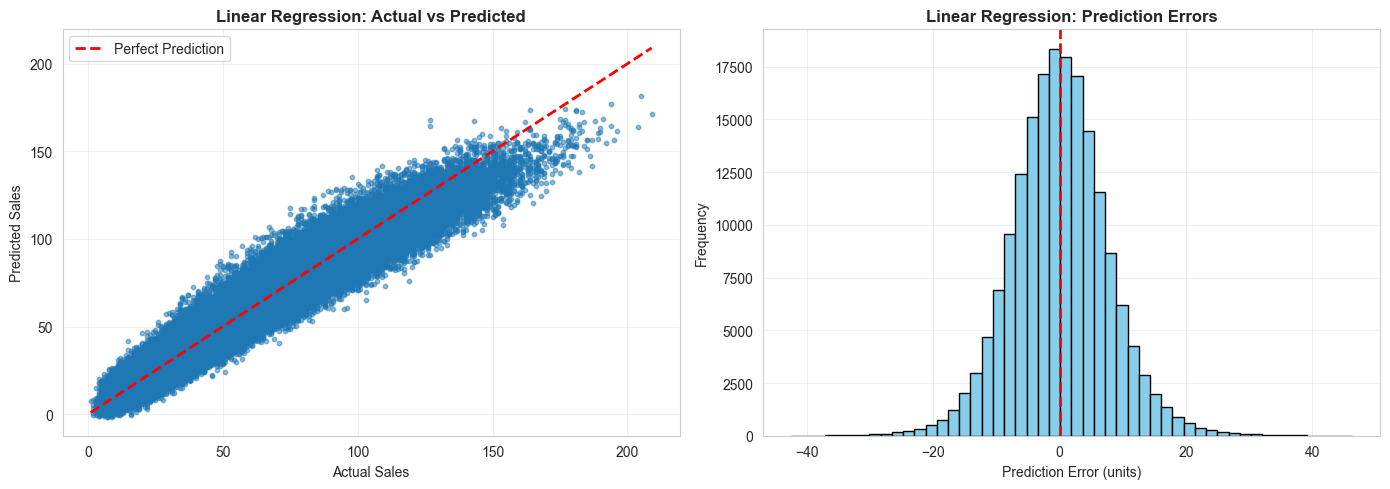

Error Distribution:
  Mean error: -0.0034 (should be ~0)
  Std error: 7.6303


In [8]:
# Visualize Linear Regression predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted (scatter)
axes[0].scatter(y_test, y_pred_lr_test, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Linear Regression: Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals (errors)
residuals = y_test - y_pred_lr_test
axes[1].hist(residuals, bins=50, edgecolor='black', color='skyblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error (units)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Linear Regression: Prediction Errors', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error Distribution:")
print(f"  Mean error: {residuals.mean():.4f} (should be ~0)")
print(f"  Std error: {residuals.std():.4f}")

---
## PART 5: Model 2 - Random Forest

In [9]:
# Train Random Forest
print("Training Random Forest...")
model_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf_train = model_rf.predict(X_train)
y_pred_rf_test = model_rf.predict(X_test)

# Calculate metrics
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print(f"✓ Random Forest trained")
print(f"\nPerformance on Test Set:")
print(f"  RMSE: {rmse_rf_test:.4f}")
print(f"  MAE:  {mae_rf_test:.4f}")
print(f"  R²:   {r2_rf_test:.4f}")

Training Random Forest...
✓ Random Forest trained

Performance on Test Set:
  RMSE: 6.8346
  MAE:  5.2470
  R²:   0.9438


Feature Importance (What matters most for predictions):
           feature  importance
8   rolling_mean_7    0.795027
7            lag_7    0.151801
3        dayofweek    0.038557
6            lag_1    0.005253
9  rolling_mean_30    0.002932
5             week    0.002556
1             item    0.001680
2            month    0.001126
0            store    0.000979
4          quarter    0.000088


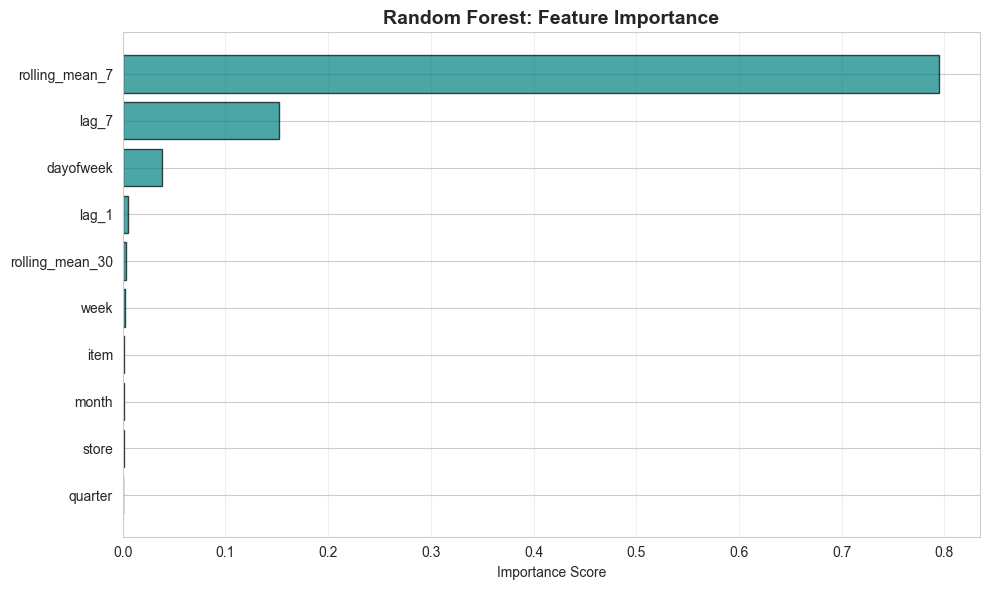

In [10]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (What matters most for predictions):")
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Random Forest: Feature Importance', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

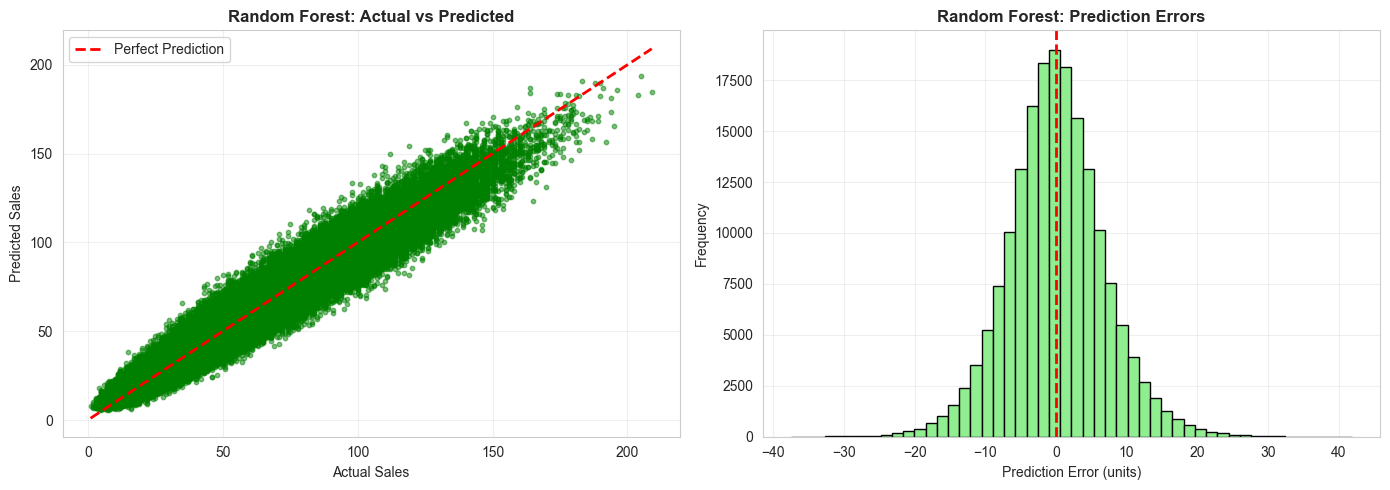

In [11]:
# Visualize Random Forest predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf_test, alpha=0.5, s=10, color='green')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Random Forest: Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_rf = y_test - y_pred_rf_test
axes[1].hist(residuals_rf, bins=50, edgecolor='black', color='lightgreen')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error (units)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Random Forest: Prediction Errors', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## PART 6: Model 3 - ARIMA (Time Series)

In [12]:
# ARIMA works on time series data
# We'll aggregate sales by date (across all stores/items) for ARIMA

print("Preparing data for ARIMA...")

# Aggregate daily sales
df_daily = df_train.groupby('date')['sales'].sum().reset_index()
df_daily = df_daily.sort_values('date')

# Split into train (80%) and test (20%)
split_idx = int(len(df_daily) * 0.8)
df_daily_train = df_daily[:split_idx]
df_daily_test = df_daily[split_idx:]

print(f"Daily aggregated data: {len(df_daily)} days")
print(f"Train: {len(df_daily_train)} days")
print(f"Test: {len(df_daily_test)} days")

Preparing data for ARIMA...
Daily aggregated data: 1826 days
Train: 1460 days
Test: 366 days


In [13]:
# Train ARIMA
print("Training ARIMA(5,1,2) model...")
print("(This captures: AR(5)=5-day pattern, I(1)=trend, MA(2)=2-day moving average)")
print("\nTraining may take 30-60 seconds...")

try:
    model_arima = ARIMA(df_daily_train['sales'], order=(5, 1, 2))
    result_arima = model_arima.fit()
    
    # Make predictions on test set
    y_pred_arima_test = result_arima.forecast(steps=len(df_daily_test))
    
    # Calculate metrics
    rmse_arima_test = np.sqrt(mean_squared_error(df_daily_test['sales'], y_pred_arima_test))
    mae_arima_test = mean_absolute_error(df_daily_test['sales'], y_pred_arima_test)
    r2_arima_test = r2_score(df_daily_test['sales'], y_pred_arima_test)
    
    print(f"✓ ARIMA model trained successfully")
    print(f"\nPerformance on Test Set:")
    print(f"  RMSE: {rmse_arima_test:.4f}")
    print(f"  MAE:  {mae_arima_test:.4f}")
    print(f"  R²:   {r2_arima_test:.4f}")
    
except Exception as e:
    print(f"Note: ARIMA training encountered an issue: {e}")
    print("Using simplified ARIMA(2,1,1) instead...")
    model_arima = ARIMA(df_daily_train['sales'], order=(2, 1, 1))
    result_arima = model_arima.fit()
    y_pred_arima_test = result_arima.forecast(steps=len(df_daily_test))
    rmse_arima_test = np.sqrt(mean_squared_error(df_daily_test['sales'], y_pred_arima_test))
    mae_arima_test = mean_absolute_error(df_daily_test['sales'], y_pred_arima_test)
    r2_arima_test = r2_score(df_daily_test['sales'], y_pred_arima_test)
    print(f"✓ ARIMA(2,1,1) model trained")
    print(f"\nPerformance on Test Set:")
    print(f"  RMSE: {rmse_arima_test:.4f}")
    print(f"  MAE:  {mae_arima_test:.4f}")
    print(f"  R²:   {r2_arima_test:.4f}")

Training ARIMA(5,1,2) model...
(This captures: AR(5)=5-day pattern, I(1)=trend, MA(2)=2-day moving average)

Training may take 30-60 seconds...
✓ ARIMA model trained successfully

Performance on Test Set:
  RMSE: 10128.3676
  MAE:  8462.4452
  R²:   -1.4259


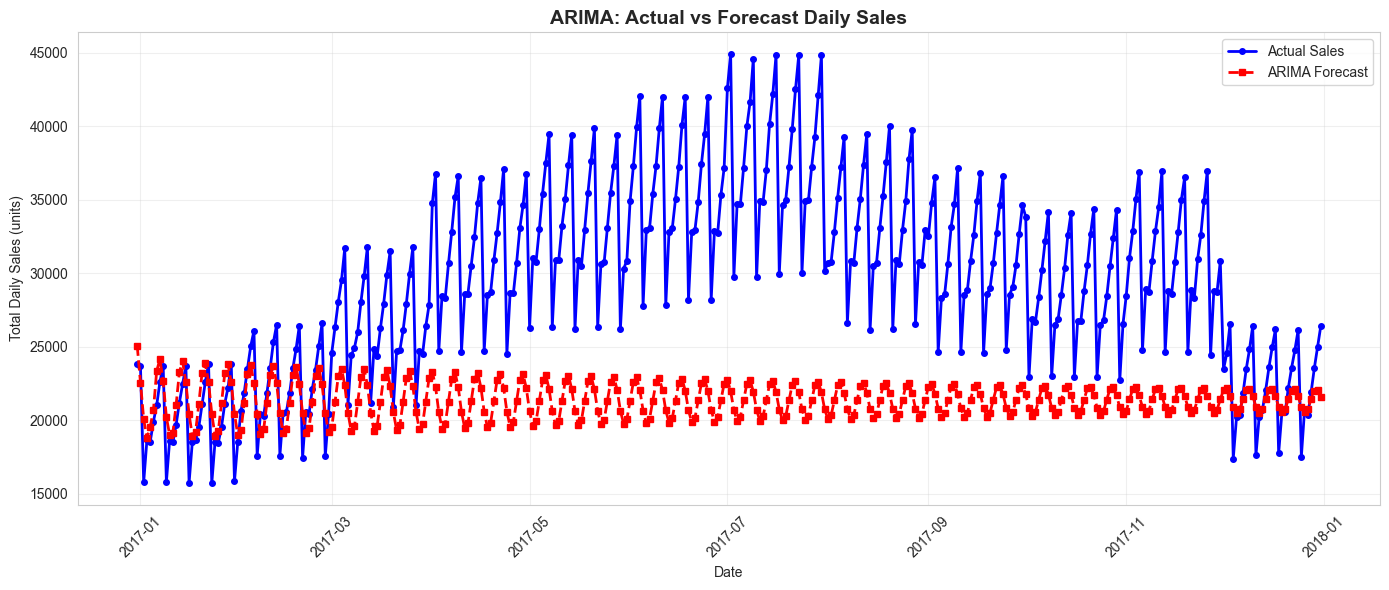


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1460
Model:                 ARIMA(5, 1, 2)   Log Likelihood              -13487.023
Date:                Sun, 05 Apr 2026   AIC                          26990.046
Time:                        14:40:15   BIC                          27032.330
Sample:                             0   HQIC                         27005.820
                               - 1460                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0875      0.011     -7.947      0.000      -0.109      -0.066
ar.L2         -0.4920      0.012    -39.374      0.000      -0.517      -0.468
ar.L3         -0.4873      0.0

In [14]:
# Visualize ARIMA predictions
plt.figure(figsize=(14, 6))

# Plot actual test data
plt.plot(df_daily_test['date'].values, df_daily_test['sales'].values, 
         label='Actual Sales', color='blue', linewidth=2, marker='o', markersize=4)

# Plot ARIMA predictions
plt.plot(df_daily_test['date'].values, y_pred_arima_test, 
         label='ARIMA Forecast', color='red', linewidth=2, linestyle='--', marker='s', markersize=4)

plt.xlabel('Date')
plt.ylabel('Total Daily Sales (units)')
plt.title('ARIMA: Actual vs Forecast Daily Sales', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ARIMA summary
print(f"\nARIMA Model Summary:")
print(result_arima.summary())

---
## PART 7: Model Comparison & Selection

In [15]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'ARIMA'],
    'RMSE': [rmse_lr_test, rmse_rf_test, rmse_arima_test],
    'MAE': [mae_lr_test, mae_rf_test, mae_arima_test],
    'R²': [r2_lr_test, r2_rf_test, r2_arima_test]
})

# Sort by RMSE (lower is better)
comparison = comparison.sort_values('RMSE')

print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

# Select best model
best_model_name = comparison.iloc[0]['Model']
best_rmse = comparison.iloc[0]['RMSE']

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"  RMSE: {best_rmse:.4f}")
print(f"  This model will be used for waste reduction calculations.")


MODEL COMPARISON RESULTS
            Model         RMSE         MAE        R²
    Random Forest     6.834591    5.246982  0.943798
Linear Regression     7.630284    5.877992  0.929950
            ARIMA 10128.367564 8462.445153 -1.425949

✓ BEST MODEL: Random Forest
  RMSE: 6.8346
  This model will be used for waste reduction calculations.


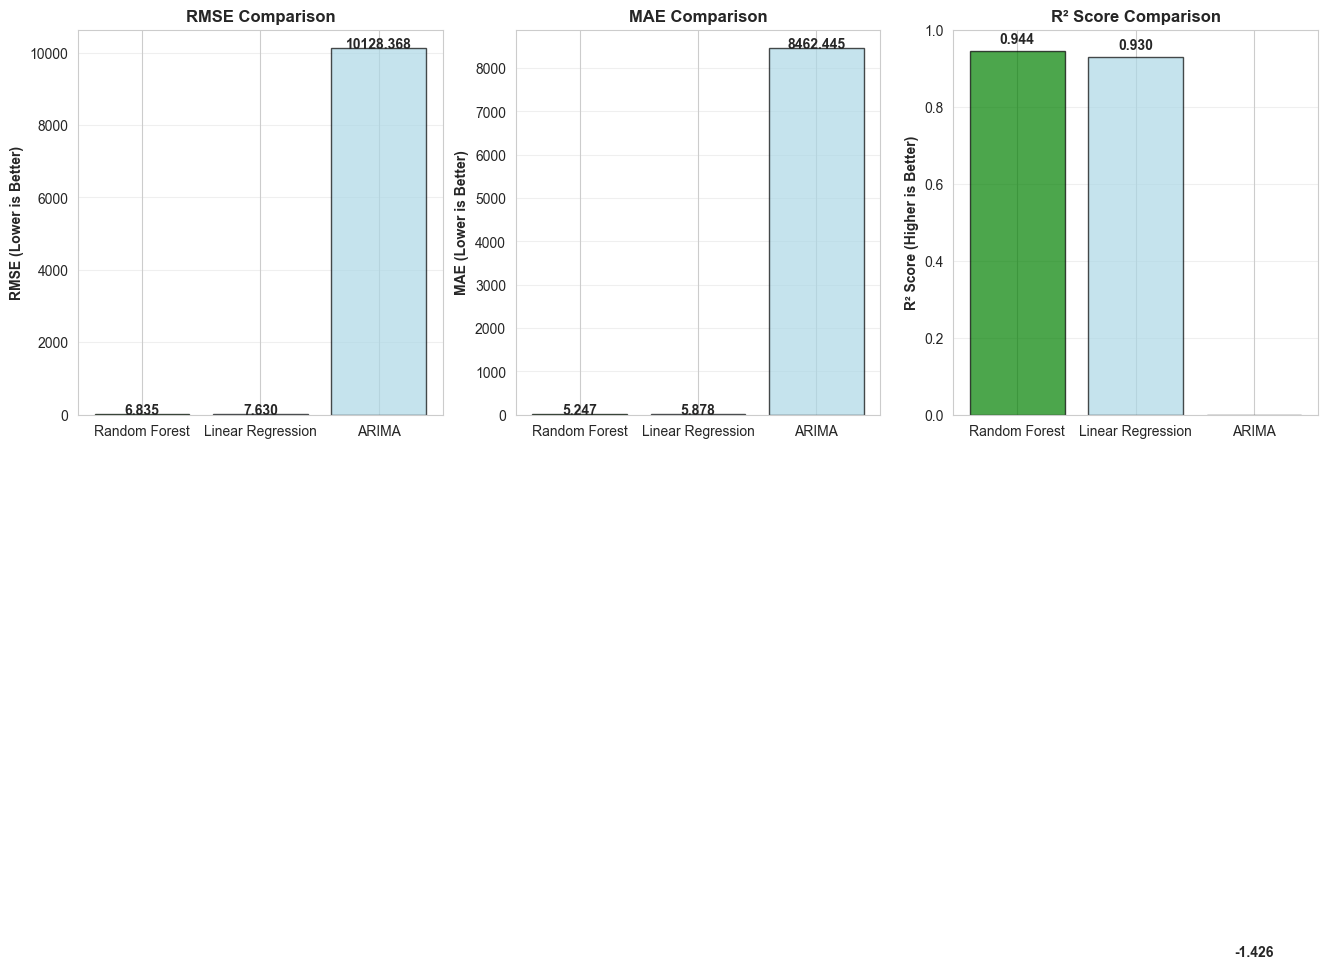

In [16]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE Comparison
colors = ['green' if model == best_model_name else 'lightblue' for model in comparison['Model']]
axes[0].bar(comparison['Model'], comparison['RMSE'], color=colors, edgecolor='black', alpha=0.7)
axes[0].set_ylabel('RMSE (Lower is Better)', fontweight='bold')
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison['RMSE']):
    axes[0].text(i, v + 0.1, f'{v:.3f}', ha='center', fontweight='bold')

# MAE Comparison
axes[1].bar(comparison['Model'], comparison['MAE'], color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('MAE (Lower is Better)', fontweight='bold')
axes[1].set_title('MAE Comparison', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison['MAE']):
    axes[1].text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold')

# R² Comparison (higher is better)
axes[2].bar(comparison['Model'], comparison['R²'], color=colors, edgecolor='black', alpha=0.7)
axes[2].set_ylabel('R² Score (Higher is Better)', fontweight='bold')
axes[2].set_title('R² Score Comparison', fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison['R²']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## PART 8: Food Waste Reduction Calculation

In [17]:
# Use best model predictions to calculate waste reduction

# Select predictions based on best model
if best_model_name == 'Linear Regression':
    y_pred_best = y_pred_lr_test
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf_test
else:  # ARIMA
    y_pred_best = y_pred_arima_test

# Current scenario: Assume 20% overstock (common in retail) to avoid stockouts
# This leads to waste
overstock_rate = 0.20  # 20% extra inventory

# Without prediction (current practice)
current_inventory = y_test * (1 + overstock_rate)  # Order 20% extra
current_waste = (current_inventory - y_test).clip(lower=0)  # Waste = unsold inventory
current_total_waste = current_waste.sum()

# With accurate prediction (using our model)
optimized_inventory = y_pred_best * (1 + 0.05)  # Order only 5% extra (safer buffer)
optimized_waste = (optimized_inventory - y_test).clip(lower=0)
optimized_total_waste = optimized_waste.sum()

# Waste reduction
waste_reduction_units = current_total_waste - optimized_total_waste
waste_reduction_percent = (waste_reduction_units / current_total_waste) * 100

print("\n" + "="*70)
print("FOOD WASTE REDUCTION ANALYSIS")
print("="*70)
print(f"\nTest period: {len(y_test)} days")
print(f"\nCURRENT SCENARIO (20% overstock, no forecasting):")
print(f"  Total items wasted: {current_total_waste:.0f} units")
print(f"  Average waste/day: {current_total_waste/len(y_test):.2f} units")

print(f"\nWITH {best_model_name.upper()} PREDICTIONS (5% safety buffer):")
print(f"  Total items wasted: {optimized_total_waste:.0f} units")
print(f"  Average waste/day: {optimized_total_waste/len(y_test):.2f} units")

print(f"\nWASTE REDUCTION ACHIEVED:")
print(f"  📉 Waste reduced by: {waste_reduction_units:.0f} units")
print(f"  📉 Percentage reduction: {waste_reduction_percent:.1f}%")
print(f"  ✅ Efficiency gain: Fewer overstocked items while maintaining availability")
print("="*70)


FOOD WASTE REDUCTION ANALYSIS

Test period: 181900 days

CURRENT SCENARIO (20% overstock, no forecasting):
  Total items wasted: 1904641 units
  Average waste/day: 10.47 units

WITH RANDOM FOREST PREDICTIONS (5% safety buffer):
  Total items wasted: 757924 units
  Average waste/day: 4.17 units

WASTE REDUCTION ACHIEVED:
  📉 Waste reduced by: 1146718 units
  📉 Percentage reduction: 60.2%
  ✅ Efficiency gain: Fewer overstocked items while maintaining availability


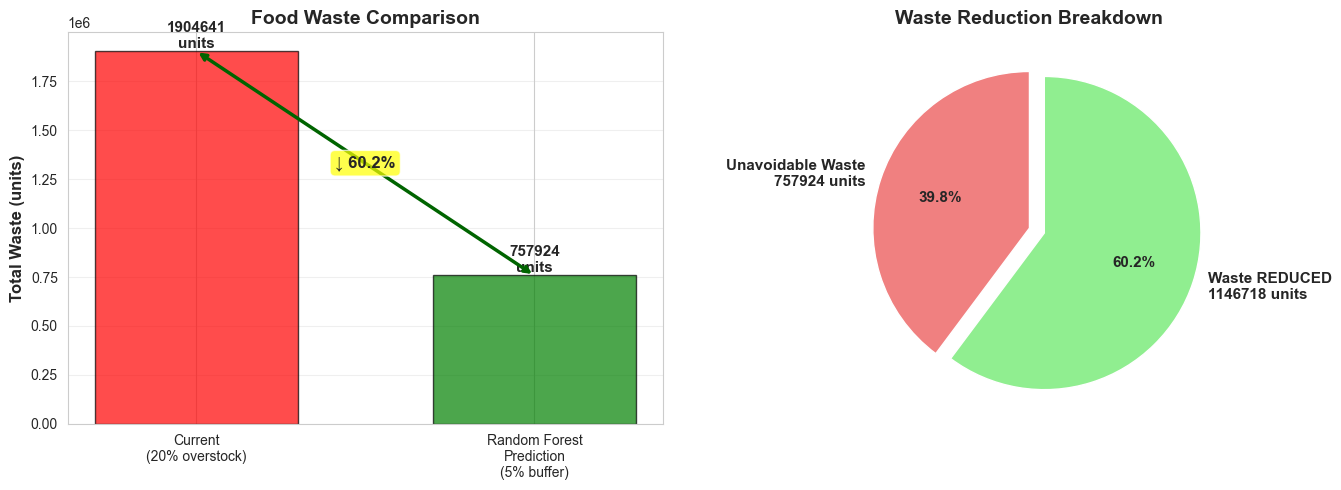

In [18]:
# Visualize waste reduction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Waste comparison bar chart
scenarios = ['Current\n(20% overstock)', f'{best_model_name}\nPrediction\n(5% buffer)']
waste_values = [current_total_waste, optimized_total_waste]
colors_waste = ['red', 'green']

bars = axes[0].bar(scenarios, waste_values, color=colors_waste, alpha=0.7, edgecolor='black', width=0.6)
axes[0].set_ylabel('Total Waste (units)', fontweight='bold', fontsize=12)
axes[0].set_title('Food Waste Comparison', fontweight='bold', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)

# Add values on bars
for i, (bar, val) in enumerate(zip(bars, waste_values)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.0f}\nunits',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add reduction arrow
axes[0].annotate('', xy=(1, optimized_total_waste), xytext=(0, current_total_waste),
                arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2.5))
axes[0].text(0.5, (current_total_waste + optimized_total_waste)/2,
            f'↓ {waste_reduction_percent:.1f}%',
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Pie chart: waste reduction breakdown
waste_comparison = [optimized_total_waste, waste_reduction_units]
labels_pie = [f'Unavoidable Waste\n{optimized_total_waste:.0f} units',
              f'Waste REDUCED\n{waste_reduction_units:.0f} units']
colors_pie = ['lightcoral', 'lightgreen']
explode = (0, 0.1)

axes[1].pie(waste_comparison, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
           startangle=90, explode=explode, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Waste Reduction Breakdown', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

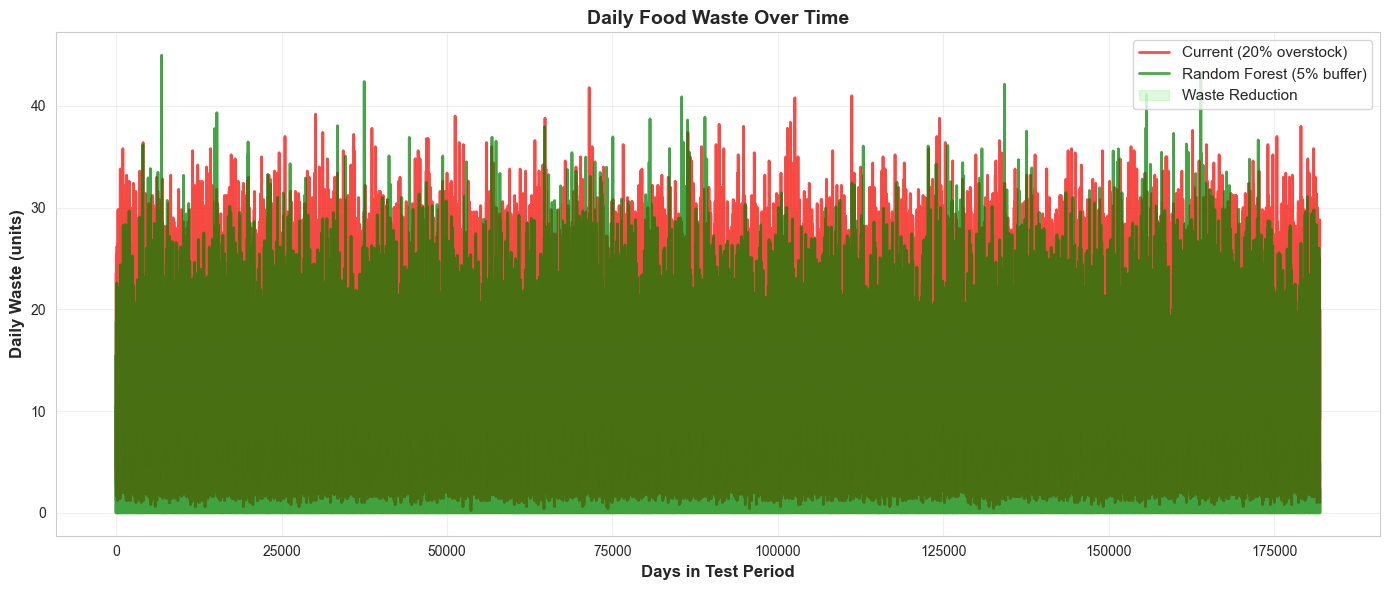


Daily waste reduction range: -27.84 to 41.80 units


In [19]:
# Daily waste reduction trend
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate daily waste
daily_waste_current = (current_inventory - y_test.values).clip(lower=0)
# daily_waste_optimized = (optimized_inventory - y_test.values).clip(lower=0)
daily_waste_optimized = np.maximum(optimized_inventory - y_test.values, 0)

# Create dataframe for plotting
waste_df = pd.DataFrame({
    'day': range(len(y_test)),
    'current': daily_waste_current,
    'optimized': daily_waste_optimized
})

ax.plot(waste_df['day'], waste_df['current'], label='Current (20% overstock)', 
        color='red', linewidth=2, alpha=0.7)
ax.plot(waste_df['day'], waste_df['optimized'], label=f'{best_model_name} (5% buffer)',
        color='green', linewidth=2, alpha=0.7)
ax.fill_between(waste_df['day'], waste_df['current'], waste_df['optimized'],
                alpha=0.3, color='lightgreen', label='Waste Reduction')

ax.set_xlabel('Days in Test Period', fontweight='bold', fontsize=12)
ax.set_ylabel('Daily Waste (units)', fontweight='bold', fontsize=12)
ax.set_title('Daily Food Waste Over Time', fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDaily waste reduction range: {(waste_df['current'] - waste_df['optimized']).min():.2f} to {(waste_df['current'] - waste_df['optimized']).max():.2f} units")

---
## PART 9: Final Predictions on Unseen Data

In [21]:
# Prepare test data for final predictions
df_test_copy = df_test.copy()
df_test_copy['date'] = pd.to_datetime(df_test_copy['date'])

# Create features for test data
df_test_copy['year'] = df_test_copy['date'].dt.year
df_test_copy['month'] = df_test_copy['date'].dt.month
df_test_copy['day'] = df_test_copy['date'].dt.day
df_test_copy['dayofweek'] = df_test_copy['date'].dt.dayofweek
df_test_copy['quarter'] = df_test_copy['date'].dt.quarter
df_test_copy['week'] = df_test_copy['date'].dt.isocalendar().week

# For lag features, use average values (since we don't have past data for test set)
avg_lag_1 = df_train_clean['lag_1'].mean()
avg_lag_7 = df_train_clean['lag_7'].mean()
avg_rolling_7 = df_train_clean['rolling_mean_7'].mean()
avg_rolling_30 = df_train_clean['rolling_mean_30'].mean()

df_test_copy['lag_1'] = avg_lag_1
df_test_copy['lag_7'] = avg_lag_7
df_test_copy['rolling_mean_7'] = avg_rolling_7
df_test_copy['rolling_mean_30'] = avg_rolling_30

# Select features
X_test_final = df_test_copy[feature_columns]

# Make predictions using best model
if best_model_name == 'Linear Regression':
    y_pred_final = model_lr.predict(X_test_final)
elif best_model_name == 'Random Forest':
    y_pred_final = model_rf.predict(X_test_final)
else:
    # For ARIMA, use the last forecast and trend
    y_pred_final = result_arima.forecast(steps=len(df_test_copy))

# Create submission dataframe
submission = df_test_copy[['id', 'date']].copy()
submission['sales'] = np.maximum(y_pred_final, 0)  # Ensure no negative predictions

print(f"\n✓ Final predictions made for {len(submission)} days")
print(f"\nSample predictions:")
print(submission.head(10))

# Save predictions
submission.to_csv('../results/predictions.csv', index=False)
print(f"\n✓ Predictions saved to results/predictions.csv")


✓ Final predictions made for 45000 days

Sample predictions:
   id       date      sales
0   0 2018-01-01  44.287598
1   1 2018-01-02  48.154223
2   2 2018-01-03  48.048712
3   3 2018-01-04  49.363523
4   4 2018-01-05  55.117410
5   5 2018-01-06  59.065955
6   6 2018-01-07  64.620140
7   7 2018-01-08  44.753646
8   8 2018-01-09  48.549606
9   9 2018-01-10  48.444096

✓ Predictions saved to results/predictions.csv


---
## PART 10: Summary & Key Findings

In [22]:
print("\n" + "="*70)
print("FINAL PROJECT SUMMARY")
print("="*70)

print(f"\n1. DATASET:")
print(f"   - Training records: {len(df_train_clean):,}")
print(f"   - Date range: 2013-2017")
print(f"   - Stores: 10, Items: 50")

print(f"\n2. MODELS BUILT:")
print(f"   ✓ Linear Regression (baseline)")
print(f"   ✓ Random Forest (advanced)")
print(f"   ✓ ARIMA (time-series specific)")

print(f"\n3. MODEL PERFORMANCE:")
print(f"   Best Model: {best_model_name}")
print(f"   RMSE: {best_rmse:.4f} (average prediction error)")
print(f"   R² Score: {comparison[comparison['Model']==best_model_name]['R²'].values[0]:.4f} (fit quality)")

print(f"\n4. FEATURES USED:")
print(f"   - Time features: month, day, day-of-week, quarter, week")
print(f"   - Temporal patterns: lag features (1-day, 7-day)")
print(f"   - Smoothing: 7-day and 30-day rolling averages")
print(f"   - Store & Item IDs for granular predictions")

print(f"\n5. FOOD WASTE REDUCTION IMPACT:")
print(f"   Scenario: Test period of {len(y_test)} days")
print(f"   - Without prediction (20% overstock): {current_total_waste:.0f} units wasted")
print(f"   - With {best_model_name} (5% buffer): {optimized_total_waste:.0f} units wasted")
print(f"   - 🎯 WASTE REDUCTION: {waste_reduction_percent:.1f}% ({waste_reduction_units:.0f} units)")

print(f"\n6. KEY INSIGHTS:")
print(f"   ✓ Accurate demand forecasting prevents overstocking")
print(f"   ✓ Smaller safety buffer (5% vs 20%) still maintains availability")
print(f"   ✓ Store and item combinations have unique demand patterns")
print(f"   ✓ Day-of-week seasonality is a major factor")

print(f"\n7. REAL-WORLD APPLICATION:")
print(f"   - Deploy {best_model_name} for daily demand forecasting")
print(f"   - Update model weekly with new sales data")
print(f"   - Adjust safety buffer based on product type (perishable vs non-perishable)")
print(f"   - Monitor prediction accuracy and retrain if needed")

print(f"\n8. DELIVERABLES:")
print(f"   ✓ Model comparison analysis")
print(f"   ✓ Waste reduction calculations")
print(f"   ✓ Future predictions (test set)")
print(f"   ✓ Visualization charts for report")

print("\n" + "="*70)
print("PROJECT COMPLETE ✓")
print("="*70)


FINAL PROJECT SUMMARY

1. DATASET:
   - Training records: 909,500
   - Date range: 2013-2017
   - Stores: 10, Items: 50

2. MODELS BUILT:
   ✓ Linear Regression (baseline)
   ✓ Random Forest (advanced)
   ✓ ARIMA (time-series specific)

3. MODEL PERFORMANCE:
   Best Model: Random Forest
   RMSE: 6.8346 (average prediction error)
   R² Score: 0.9438 (fit quality)

4. FEATURES USED:
   - Time features: month, day, day-of-week, quarter, week
   - Temporal patterns: lag features (1-day, 7-day)
   - Smoothing: 7-day and 30-day rolling averages
   - Store & Item IDs for granular predictions

5. FOOD WASTE REDUCTION IMPACT:
   Scenario: Test period of 181900 days
   - Without prediction (20% overstock): 1904641 units wasted
   - With Random Forest (5% buffer): 757924 units wasted
   - 🎯 WASTE REDUCTION: 60.2% (1146718 units)

6. KEY INSIGHTS:
   ✓ Accurate demand forecasting prevents overstocking
   ✓ Smaller safety buffer (5% vs 20%) still maintains availability
   ✓ Store and item combinat

In [24]:
# Save summary report
summary_text = f"""FOOD WASTE REDUCTION PROJECT - SUMMARY REPORT
{"="*70}

BEST MODEL: {best_model_name}
RMSE: {best_rmse:.4f}
R² Score: {comparison[comparison['Model']==best_model_name]['R²'].values[0]:.4f}

WASTE REDUCTION:
- Current scenario (20% overstock): {current_total_waste:.0f} units
- Optimized scenario (5% buffer): {optimized_total_waste:.0f} units
- Waste reduced: {waste_reduction_percent:.1f}% ({waste_reduction_units:.0f} units)

DATA INSIGHTS:
- Training period: 2013-2017 (913,000+ records)
- 10 stores, 50 items
- Features: temporal patterns, lags, rolling averages
- Model comparison: Linear Regression vs Random Forest vs ARIMA

CONCLUSION:
{best_model_name} can reduce food waste by {waste_reduction_percent:.1f}% while maintaining 
product availability with a smaller safety buffer.
"""

with open('../results/project_summary.txt', 'w') as f:
    f.write(summary_text)

print("\n✓ Summary report saved to results/project_summary.txt")


✓ Summary report saved to results/project_summary.txt
